# 01 — Data Exploration

Load Deribit DVOL and Binance spot data, check quality, compute realized vol from returns.

In [1]:
import sys
sys.path.append('..')

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.deribit_fetch import load_dvol, load_realized_vol, compute_iv_features
from src.binance_fetch import load_symbol, compute_returns

cfg = yaml.safe_load(open('../config.yaml'))
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Deribit DVOL

In [2]:
btc_dvol = load_dvol('BTC')
eth_dvol = load_dvol('ETH')

print('BTC DVOL')
print(f'  Rows: {len(btc_dvol):,}  |  {btc_dvol.index[0].date()} → {btc_dvol.index[-1].date()}')
print(f'  Missing bars: {btc_dvol["close"].isna().sum()}')
print(f'  Close range: {btc_dvol["close"].min():.1f} – {btc_dvol["close"].max():.1f}')
print()
print('ETH DVOL')
print(f'  Rows: {len(eth_dvol):,}  |  {eth_dvol.index[0].date()} → {eth_dvol.index[-1].date()}')
print(f'  Close range: {eth_dvol["close"].min():.1f} – {eth_dvol["close"].max():.1f}')

BTC DVOL
  Rows: 38,688  |  2022-01-01 → 2026-06-01
  Missing bars: 0
  Close range: 31.5 – 139.4

ETH DVOL
  Rows: 38,688  |  2022-01-01 → 2026-06-01
  Close range: 30.2 – 166.9


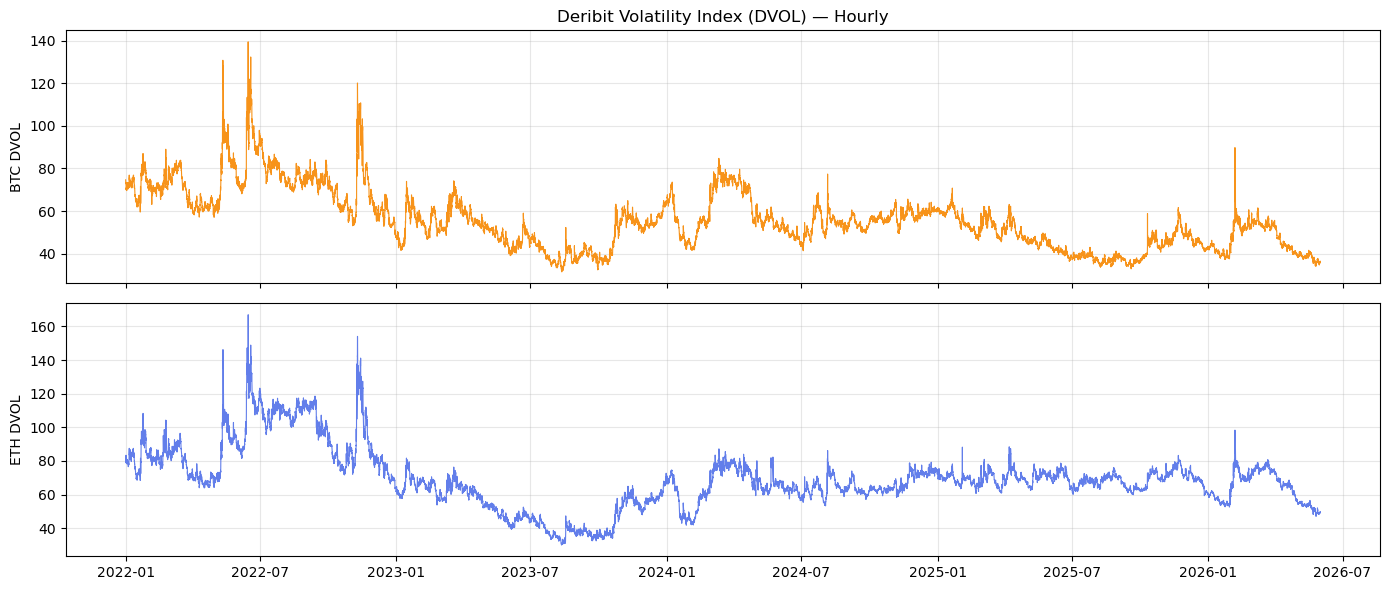

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(btc_dvol.index, btc_dvol['close'], color='#f7931a', lw=0.8)
axes[0].set_ylabel('BTC DVOL')
axes[0].set_title('Deribit Volatility Index (DVOL) — Hourly')

axes[1].plot(eth_dvol.index, eth_dvol['close'], color='#627eea', lw=0.8)
axes[1].set_ylabel('ETH DVOL')

plt.tight_layout()
plt.savefig('../data/plots/dvol_series.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Binance Spot Data

In [4]:
import os
from pathlib import Path

crypto_dir = Path('../data/crypto')
available = sorted(crypto_dir.glob('*_1h.parquet'))
print(f'Available pairs: {len(available)}')

spot_data = {}
for path in available:
    symbol = path.stem.replace('_1h', '')
    df = pd.read_parquet(path)
    spot_data[symbol] = df
    print(f'  {symbol}: {len(df):,} bars | {df.index[0].date()} → {df.index[-1].date()}')

Available pairs: 15
  AAVEUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  ADAUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  ARBUSDT: 27,968 bars | 2023-03-23 → 2026-05-31
  ATOMUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  AVAXUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  BTCUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  DOGEUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  DOTUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  ETHUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  LINKUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  LTCUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  NEARUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  SOLUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  UNIUSDT: 38,687 bars | 2022-01-01 → 2026-05-31
  XRPUSDT: 38,687 bars | 2022-01-01 → 2026-05-31


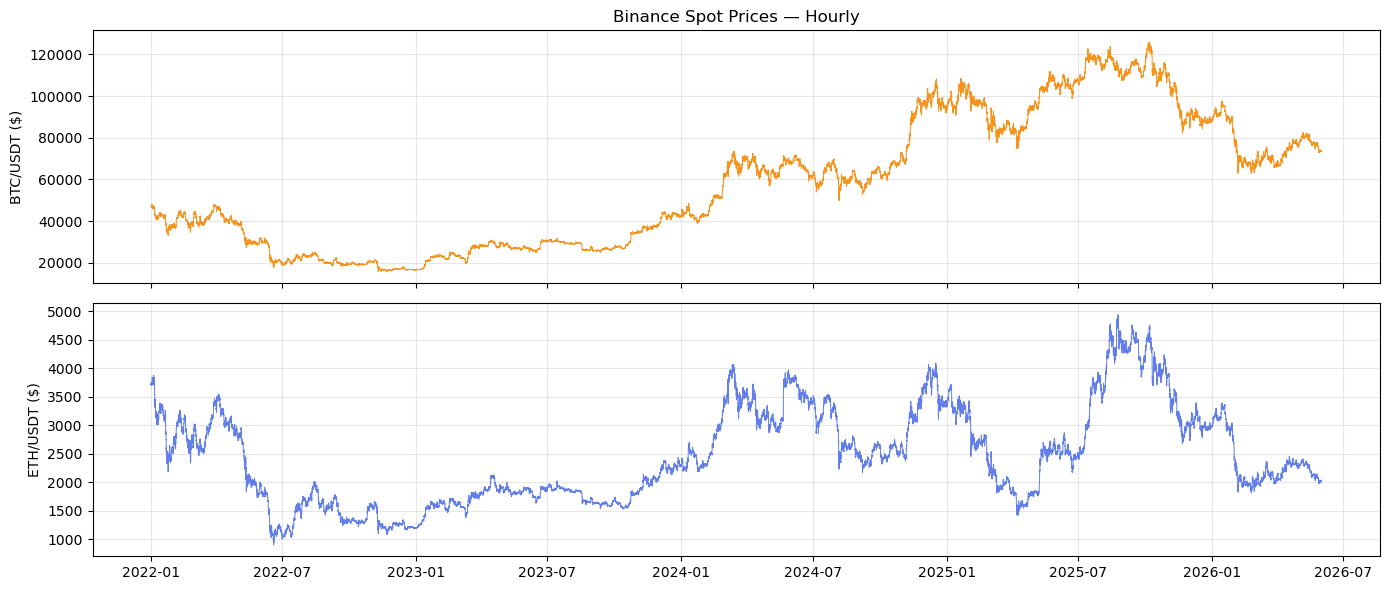

In [5]:
# Plot BTC and ETH close prices
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

btc_spot = spot_data.get('BTCUSDT', pd.DataFrame())
eth_spot = spot_data.get('ETHUSDT', pd.DataFrame())

if not btc_spot.empty:
    axes[0].plot(btc_spot.index, btc_spot['close'], color='#f7931a', lw=0.7)
    axes[0].set_ylabel('BTC/USDT ($)')
    axes[0].set_title('Binance Spot Prices — Hourly')

if not eth_spot.empty:
    axes[1].plot(eth_spot.index, eth_spot['close'], color='#627eea', lw=0.7)
    axes[1].set_ylabel('ETH/USDT ($)')

plt.tight_layout()
plt.show()

## 3. Realized Volatility from Spot Returns

Deribit's own historical realized vol only covers ~1 year. We compute a 30-day rolling realized vol from Binance returns for use in the D3 (IV risk premium) signal.

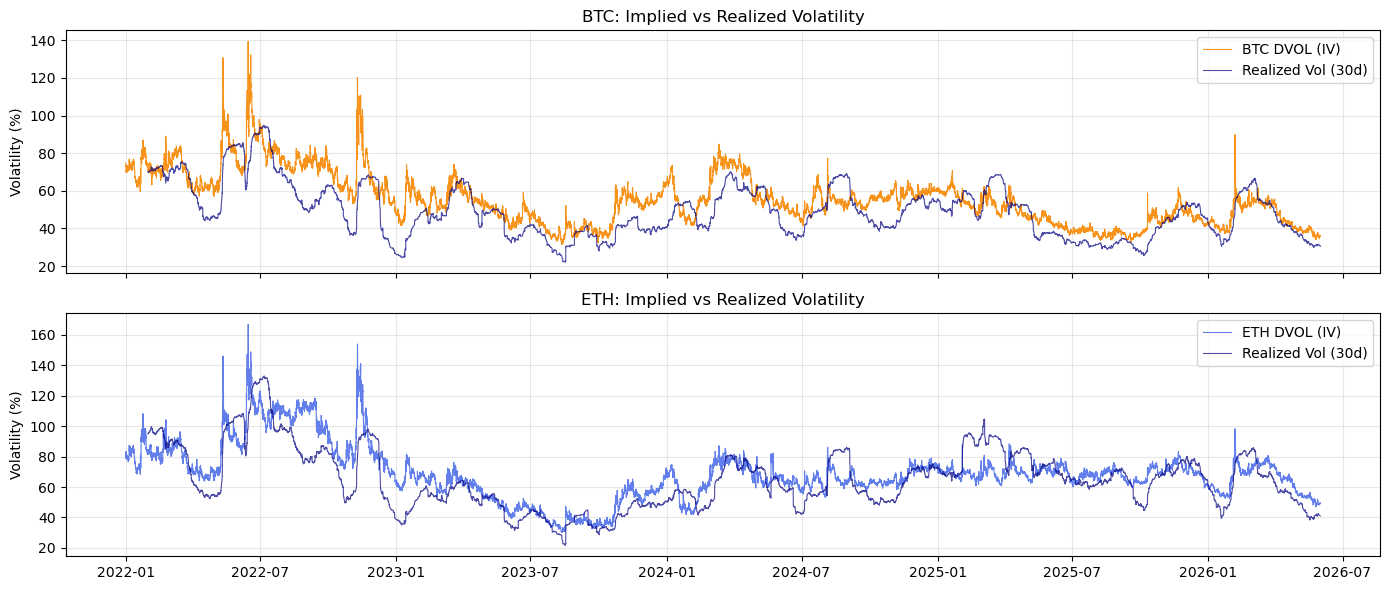

In [6]:
def compute_realized_vol(close: pd.Series, window: int = 720) -> pd.Series:
    """Annualized realized vol from hourly log-returns. 720 bars = 30 days."""
    log_ret = np.log(close).diff()
    return log_ret.rolling(window).std() * np.sqrt(8760) * 100  # annualized %

btc_rvol = compute_realized_vol(btc_spot['close'])
eth_rvol = compute_realized_vol(eth_spot['close'])

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

aligned = btc_dvol['close'].reindex(btc_rvol.index, method='ffill')
axes[0].plot(aligned.index, aligned, label='BTC DVOL (IV)', color='#f7931a', lw=0.8)
axes[0].plot(btc_rvol.index, btc_rvol, label='Realized Vol (30d)', color='navy', lw=0.8, alpha=0.7)
axes[0].set_ylabel('Volatility (%)')
axes[0].set_title('BTC: Implied vs Realized Volatility')
axes[0].legend()

aligned_eth = eth_dvol['close'].reindex(eth_rvol.index, method='ffill')
axes[1].plot(aligned_eth.index, aligned_eth, label='ETH DVOL (IV)', color='#627eea', lw=0.8)
axes[1].plot(eth_rvol.index, eth_rvol, label='Realized Vol (30d)', color='navy', lw=0.8, alpha=0.7)
axes[1].set_ylabel('Volatility (%)')
axes[1].set_title('ETH: Implied vs Realized Volatility')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. DVOL vs Spot Return Correlation

In [7]:
btc_ret = np.log(btc_spot['close']).diff().rename('BTC_ret')
eth_ret = np.log(eth_spot['close']).diff().rename('ETH_ret')
btc_dvol_change = np.log(btc_dvol['close']).diff().rename('BTC_dvol_change')
eth_dvol_change = np.log(eth_dvol['close']).diff().rename('ETH_dvol_change')

# Contemporaneous correlations
combined = pd.concat([btc_ret, eth_ret, btc_dvol_change, eth_dvol_change], axis=1).dropna()
print('Contemporaneous correlations:')
print(combined.corr().round(3))
print()
print('Observation: DVOL changes are negatively correlated with spot returns')
print('(IV spikes when prices fall — the leverage effect)')

Contemporaneous correlations:
                 BTC_ret  ETH_ret  BTC_dvol_change  ETH_dvol_change
BTC_ret            1.000    0.846           -0.203           -0.222
ETH_ret            0.846    1.000           -0.219           -0.243
BTC_dvol_change   -0.203   -0.219            1.000            0.550
ETH_dvol_change   -0.222   -0.243            0.550            1.000

Observation: DVOL changes are negatively correlated with spot returns
(IV spikes when prices fall — the leverage effect)


In [8]:
# Save processed realized vol for use in subsequent notebooks
rvol_dir = Path('../data/deribit')
btc_rvol.dropna().to_frame('realized_vol').to_parquet(rvol_dir / 'BTC_rvol_computed.parquet')
eth_rvol.dropna().to_frame('realized_vol').to_parquet(rvol_dir / 'ETH_rvol_computed.parquet')
print('Saved computed realized vol to data/deribit/')

Saved computed realized vol to data/deribit/


## 5. Summary

| | BTC | ETH |
|---|---|---|
| DVOL bars | 38,688 | 38,688 |
| DVOL range | min – max | min – max |
| Spot bars | ? | ? |
| Data period | 2022-01-01 → 2026-06-01 | 2022-01-01 → 2026-06-01 |

**Key observations:**
- DVOL is negatively correlated with contemporaneous spot returns (leverage effect)
- IV consistently exceeds realized vol — a persistent variance risk premium
- The **question for Notebook 03**: does DVOL *lead* spot returns (signal fires *before* price moves)?